# Balance dataset

In [1]:
import pandas as pd

In [2]:
data_train = pd.read_csv('data/dataset_train_resized_fixed.csv')
data_test = pd.read_csv('data/dataset_test_resized_fixed.csv')
data_val = pd.read_csv('data/dataset_val_resized_fixed.csv')

In [5]:
# Drop PELVIS, ELBOW, ABDOMEN, HUMERUS, FEMUR in xray_type column
data_train = data_train[~data_train['xray_type'].isin(['PELVIS', 'ELBOW', 'ABDOMEN', 'HUMERUS', 'FEMUR'])]
data_test = data_test[~data_test['xray_type'].isin(['PELVIS', 'ELBOW', 'ABDOMEN', 'HUMERUS', 'FEMUR'])]
data_val = data_val[~data_val['xray_type'].isin(['PELVIS', 'ELBOW', 'ABDOMEN', 'HUMERUS', 'FEMUR'])]

# Keep only age from 7 to 90 in Age column
data_train = data_train[(data_train['Age'] >= 7) & (data_train['Age'] <= 90)]
data_test = data_test[(data_test['Age'] >= 7) & (data_test['Age'] <= 90)]
data_val = data_val[(data_val['Age'] >= 7) & (data_val['Age'] <= 90)]

In [6]:
# Analyze after balancing
xray_types_train = data_train['xray_type'].value_counts()
print(xray_types_train)
xray_types_test = data_test['xray_type'].value_counts()
print(xray_types_test)
xray_types_val = data_val['xray_type'].value_counts()
print(xray_types_val)

xray_type
CHEST       5629
SKULL       2029
SPINE       1383
KNEE         909
WRIST        641
SHOULDER     462
FOREARM      398
FOOT         394
ANKLE        326
HAND         291
Name: count, dtype: int64
xray_type
CHEST       1566
SKULL        570
SPINE        392
KNEE         274
WRIST        180
SHOULDER     156
FOOT         124
FOREARM      124
HAND          87
ANKLE         86
Name: count, dtype: int64
xray_type
CHEST       776
SKULL       308
SPINE       202
KNEE        145
WRIST        94
FOREARM      60
SHOULDER     56
FOOT         51
ANKLE        49
HAND         29
Name: count, dtype: int64


Age
7     102
8      96
9     111
10    119
11    118
     ... 
86     26
87     32
88     33
89     28
90     17
Name: count, Length: 84, dtype: int64
Age
7     29
8     31
9     26
10    39
11    32
      ..
86     5
87    11
88    16
89     4
90     3
Name: count, Length: 84, dtype: int64
Age
7     14
8      9
9     14
10    14
11    24
      ..
86     2
87     7
88     4
89     6
90     3
Name: count, Length: 84, dtype: int64


<Axes: xlabel='Age'>

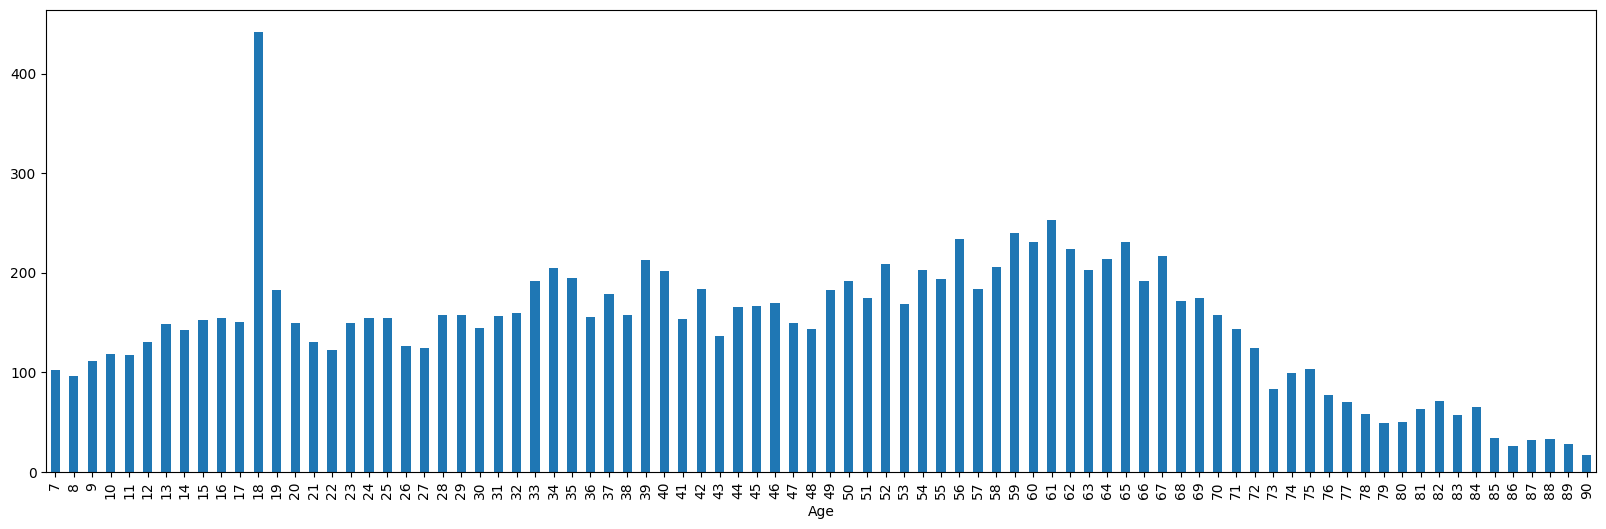

In [7]:
age_counts_train = data_train['Age'].value_counts().sort_index()
print(age_counts_train)
age_counts_train.plot(kind='bar', figsize=(20, 6))

age_counts_test = data_test['Age'].value_counts().sort_index()
print(age_counts_test)
age_counts_test.plot(kind='bar', figsize=(20, 6))

age_counts_val = data_val['Age'].value_counts().sort_index()
print(age_counts_val)
age_counts_val.plot(kind='bar', figsize=(20, 6))

In [8]:
# Save the balanced datasets
data_train.to_csv('balancedData/dataset_train_resized_balanced.csv', index=False)
data_test.to_csv('balancedData/dataset_test_resized_balanced.csv', index=False)
data_val.to_csv('balancedData/dataset_val_resized_balanced.csv', index=False)

# Balance label dataset

In [9]:
# Check balance data in label column after balancing
label_counts_train = data_train['label'].value_counts()
print(label_counts_train)
label_counts_test = data_test['label'].value_counts()
print(label_counts_test)
label_counts_val = data_val['label'].value_counts()
print(label_counts_val)

label
['NORMAL']                                                   6677
['OTHER']                                                    1574
['FRACTURE']                                                 1477
['DEGENERATION']                                              904
['TUBERCULOSIS']                                              339
                                                             ... 
['TUBERCULOSIS', 'SINUSITIS']                                   1
['TUBERCULOSIS', 'FRACTURE', 'DEGENERATION']                    1
['DEGENERATION', 'SINUSITIS']                                   1
['CARDIOMEGALY', 'DEGENERATION', 'HARDWARE/SURGERY']            1
['PNEUMONIA/INFILTRATION', 'TUBERCULOSIS', 'SOFT_TISSUE']       1
Name: count, Length: 84, dtype: int64
label
['NORMAL']                                                        1913
['OTHER']                                                          445
['FRACTURE']                                                       412
['DEGENERAT